# 01 - Veri Keşfi (Exploration)

**Amaç**: Event-level e-ticaret verisinden türetilen session-level veri setinin yapısını, hedef değişken dağılımını ve feature davranışlarını görsel olarak incelemek.

*Veri kaynağı*: Kaggle `mkechinov/ecommerce-events-history-in-cosmetics-shop` (4 aylık CSV, ~16M event). Aggregation Phase 1'de tamamlandı.  
*Girdi*: `data/processed/sessions_all.parquet`, `data/processed/sessions_cat.parquet`

In [ ]:
import sys, warnings
from pathlib import Path
warnings.filterwarnings("ignore")
sys.path.insert(0, "..")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.feature_engineering import FEATURE_COLS

DATA = Path("..") / "data" / "processed"
pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 140)
plt.rcParams["figure.dpi"] = 110


## 1. Dataset'i yükle

In [ ]:
sessions_all = pd.read_parquet(DATA / "sessions_all.parquet")
sessions_cat = pd.read_parquet(DATA / "sessions_cat.parquet")
print(f"sessions_all: {sessions_all.shape[0]:,} rows x {sessions_all.shape[1]} cols")
print(f"sessions_cat: {sessions_cat.shape[0]:,} rows x {sessions_cat.shape[1]} cols")
sessions_all.head(3)

sessions_all: 3,599,496 rows x 18 cols
sessions_cat: 131,297 rows x 18 cols


,user_session,user_id,n_view,n_cart,n_remove,n_events,avg_price,max_price,min_price,price_std,unique_products,unique_categories,has_brand,purchased,main_cat,session_duration_sec,cart_to_view_ratio,remove_to_cart_ratio
0,000013d6-68a4-40cf-9452-6577dbfab515,405771061,2,1,8,11,1.262727,5.56,0.38,1.559314,9,6,1,1,NaN,7425.0,0.5,8.0
1,000027d7-5077-4a81-89de-ce2c4936a28f,437891561,1,0,0,1,15.790000,15.79,15.79,0.000000,1,1,0,0,NaN,0.0,0.0,0.0
2,00002e32-16ef-4770-9ec0-36ef9d1c888f,534154250,1,0,0,1,3.790000,3.79,3.79,0.000000,1,1,0,0,NaN,0.0,0.0,0.0


## 2. Hedef değişken: purchased

Session bazında **~%3.3** purchase oranı. Ciddi class imbalance — bu yüzden doğrudan Accuracy yerine F1/ROC-AUC kullanacağız.

purchase rate: 0.0332
purchased
no_purchase    3480072
purchase        119424
Name: count, dtype: int64


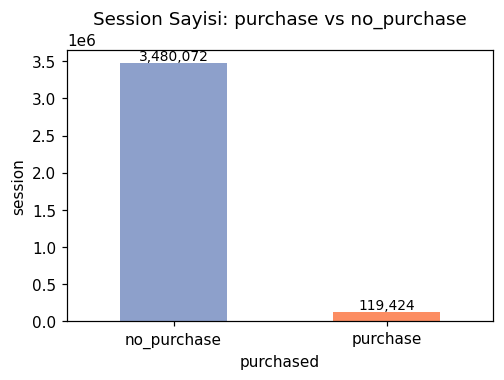

In [ ]:
pur_rate = sessions_all["purchased"].mean()
counts = sessions_all["purchased"].value_counts().rename({0: "no_purchase", 1: "purchase"})
print(f"purchase rate: {pur_rate:.4f}")
print(counts)

fig, ax = plt.subplots(figsize=(5, 3.2))
counts.plot.bar(ax=ax, color=["#8da0cb", "#fc8d62"])
ax.set_title("Session Sayisi: purchase vs no_purchase")
ax.set_ylabel("session")
ax.tick_params(axis="x", rotation=0)
for p in ax.patches:
    ax.annotate(f"{int(p.get_height()):,}", (p.get_x()+p.get_width()/2, p.get_height()),
                ha="center", va="bottom", fontsize=9)
plt.show()

## 3. Kategori dağılımı (Model 2 subset)

`category_id → category_code` mapping'i ile doldurulmuş sessionlar. 5 ana kategori: appliances baskın, accessories minority.

,count,share
main_cat,,
appliances,59522,0.453339
furniture,24462,0.186310
apparel,19037,0.144992
stationery,15977,0.121686
accessories,12299,0.093673


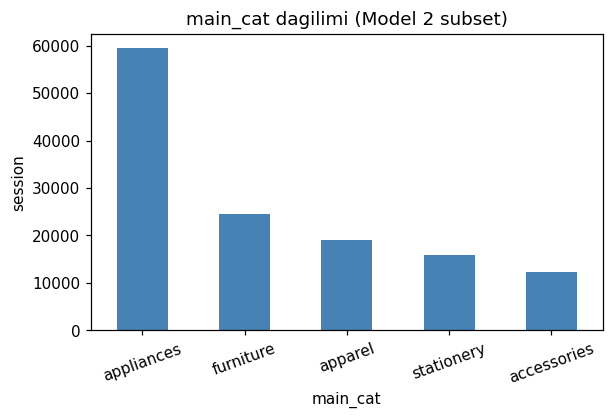

In [ ]:
cat_counts = sessions_cat["main_cat"].value_counts()
display(cat_counts.to_frame("count").assign(share=lambda d: d["count"] / d["count"].sum()))

fig, ax = plt.subplots(figsize=(6, 3.5))
cat_counts.plot.bar(ax=ax, color="steelblue")
ax.set_title("main_cat dagilimi (Model 2 subset)")
ax.set_ylabel("session")
ax.tick_params(axis="x", rotation=20)
plt.show()

## 4. Feature özeti

14 session-level feature'ın ortalama/medyan/aralık değerleri. Ağır kuyruklu dağılımlar (session_duration, n_events) outlier'ların varlığına işaret eder.

In [ ]:
sessions_all[FEATURE_COLS].describe().T[["mean", "50%", "std", "min", "max"]]\
    .round(3)

,mean,50%,std,min,max
n_view,2.106,1.00,5.332,0.00,3.350000e+03
n_cart,1.237,0.00,6.428,0.00,3.749000e+03
n_remove,0.848,0.00,7.231,0.00,3.396000e+03
n_events,4.192,1.00,14.400,0.00,5.411000e+03
cart_to_view_ratio,0.383,0.00,2.265,0.00,8.700000e+02
remove_to_cart_ratio,0.274,0.00,3.189,0.00,1.866000e+03
avg_price,13.801,5.40,27.169,-79.37,3.277800e+02
max_price,16.332,6.27,31.218,-79.37,3.277800e+02
min_price,12.413,4.73,26.317,-79.37,3.277800e+02
price_std,1.591,0.00,7.241,0.00,2.312450e+02


## 5. Feature dağılımları

Ağır kuyruk nedeniyle log-scale histogramlar. `n_events` ve `session_duration_sec` özellikle geniş spektruma yayılıyor.

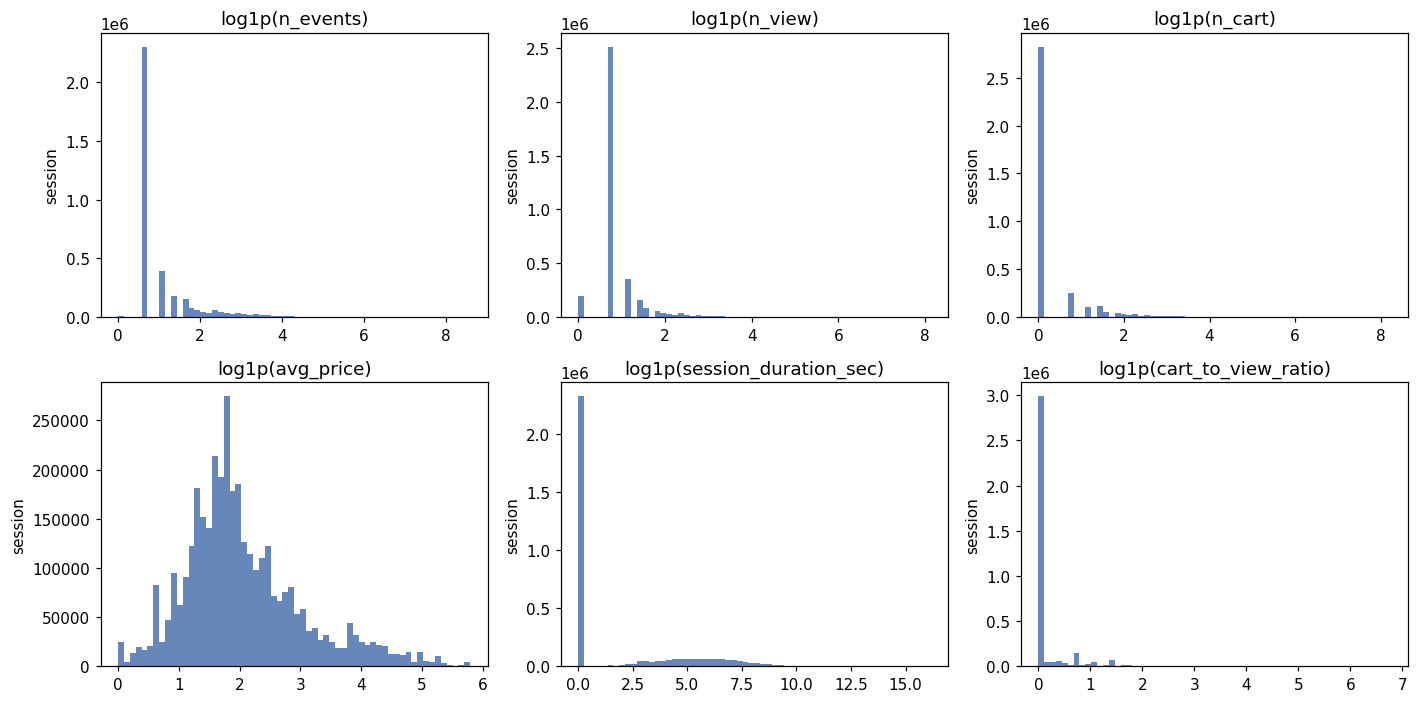

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(13, 6.5))
cols = ["n_events", "n_view", "n_cart", "avg_price", "session_duration_sec", "cart_to_view_ratio"]
for ax, col in zip(axes.ravel(), cols):
    data = sessions_all[col].replace([np.inf, -np.inf], np.nan).dropna()
    data = data[data >= 0]
    ax.hist(np.log1p(data), bins=60, color="#4c72b0", alpha=0.85)
    ax.set_title(f"log1p({col})")
    ax.set_ylabel("session")
plt.tight_layout()
plt.show()

## 6. Davranış farkı: purchased vs no_purchase

Her feature'in class bazında ortalaması — purchased session'lar belirgin şekilde daha yüksek etkileşim ve kartlama sergiliyor.

In [ ]:
cmp = sessions_all.groupby("purchased")[FEATURE_COLS].mean().T
cmp.columns = ["no_purchase", "purchase"]
cmp["ratio"] = cmp["purchase"] / cmp["no_purchase"].replace(0, np.nan)
display(cmp.round(3))

,no_purchase,purchase,ratio
n_view,1.966,6.186,3.146
n_cart,1.025,7.418,7.236
n_remove,0.693,5.363,7.734
n_events,3.685,18.967,5.147
cart_to_view_ratio,0.335,1.783,5.324
remove_to_cart_ratio,0.249,0.994,3.987
avg_price,14.014,7.582,0.541
max_price,16.327,16.455,1.008
min_price,12.697,4.152,0.327
price_std,1.517,3.751,2.472


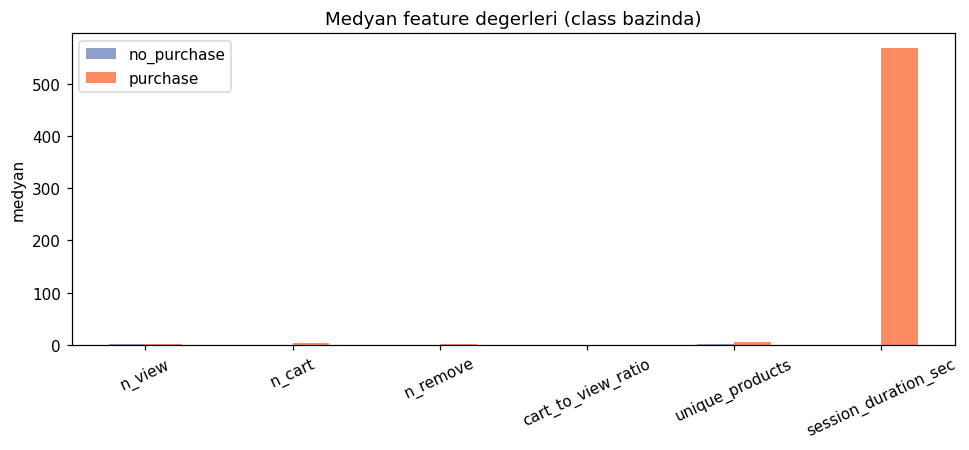

In [ ]:
key_feats = ["n_view", "n_cart", "n_remove", "cart_to_view_ratio",
             "unique_products", "session_duration_sec"]
fig, ax = plt.subplots(figsize=(9, 4.2))
medians = sessions_all.groupby("purchased")[key_feats].median().T
medians.columns = ["no_purchase", "purchase"]
medians.plot.bar(ax=ax, color=["#8da0cb", "#fc8d62"])
ax.set_title("Medyan feature degerleri (class bazinda)")
ax.set_ylabel("medyan")
ax.tick_params(axis="x", rotation=25)
ax.legend(title="")
plt.tight_layout()
plt.show()

## 7. Feature korelasyonu

Count feature'ları (`n_view/n_cart/n_remove/n_events`) beklendiği üzere yüksek korelasyonlu; fiyat feature'ları (`avg/max/min_price`) kendi aralarında kümeleniyor.

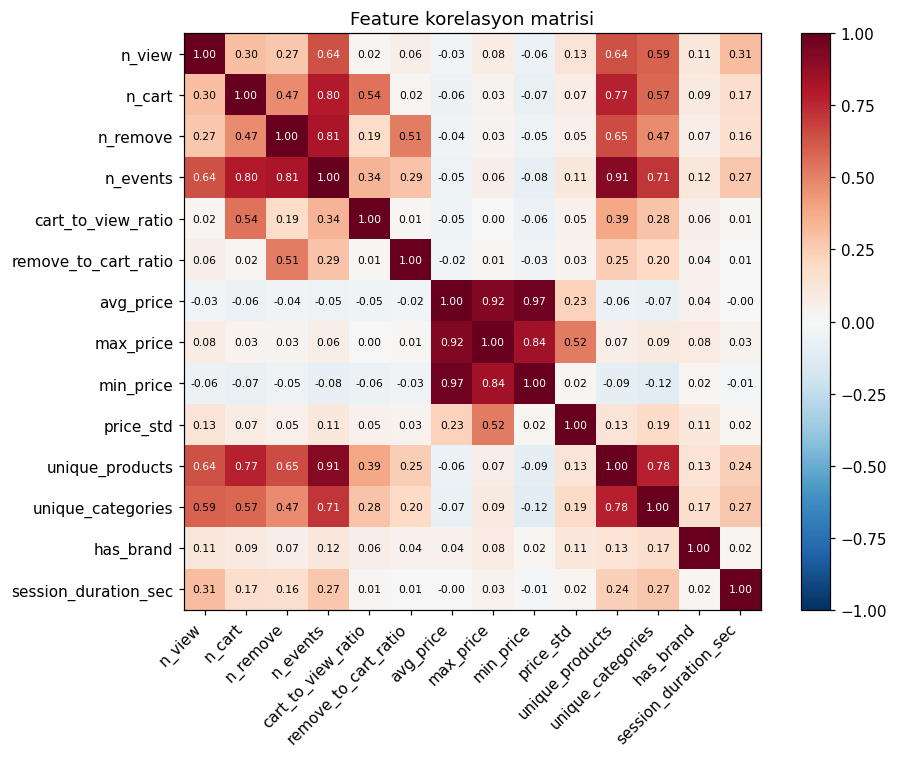

In [ ]:
corr = sessions_all[FEATURE_COLS].corr()
fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr, cmap="RdBu_r", vmin=-1, vmax=1)
ax.set_xticks(range(len(FEATURE_COLS)))
ax.set_yticks(range(len(FEATURE_COLS)))
ax.set_xticklabels(FEATURE_COLS, rotation=45, ha="right")
ax.set_yticklabels(FEATURE_COLS)
for i in range(len(FEATURE_COLS)):
    for j in range(len(FEATURE_COLS)):
        ax.text(j, i, f"{corr.iat[i, j]:.2f}", ha="center", va="center",
                color="black" if abs(corr.iat[i, j]) < 0.6 else "white", fontsize=7)
fig.colorbar(im, ax=ax)
ax.set_title("Feature korelasyon matrisi")
plt.tight_layout()
plt.show()

## 8. Bulgu özeti

- **Imbalance**: %3.32 purchase — baseline "hep 0 tahmin et" %96.7 accuracy almak için yeterli, ama F1=0. Bu yüzden F1/ROC-AUC öncelikli.
- **Category subset**: 131,297 session (%3.6'sı ana veriden) — appliances %45 baskın, accessories %9.
- **Davranış sinyali güçlü**: Purchased session'lar ortalama ~17 event vs ~3.9; `cart_to_view_ratio` ve `unique_products` net ayrıcı.
- **Feature mühendisliği kararı**: Tüm feature'lar non-purchase event'ler üzerinden hesaplandı — hedef sızıntısı yok.
